
# Pitch decay calibratie op ongefilterd signaal, start simulatie op A2

Dit notebook doet de analyse voor **één dataset**:
- gebruikt het **ongefilterde** pitchsignaal
- bepaalt een **rustniveau** uit een quiet window
- zoekt daarna het **eerste geldige extremum A1** na die rustige periode, met **|amplitude| > 2 deg**
- bepaalt of dat extremum een **piek** of een **dal** is
- zoekt het **volgende extremum van hetzelfde type** als **A2**
- bepaalt de gemiddelde periode uit meerdere extrema van datzelfde type
- start de OrcaFlex-simulatie op **tijdstip A2** met **InitialTrim = A2**
- fit daarna **alle pieken en dalen in 100 s vanaf A2**
- berekent **NRMSE pieken** en **NRMSE dalen** apart
- maakt een plot van het originele ongefilterde signaal met **A1**, **A2** en de simulatie die start op **A2**


In [25]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import OrcFxAPI

from pathlib import Path
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (15, 7)
plt.rcParams["axes.grid"] = True


In [26]:

# =========================
# PADEN
# =========================
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_fixed_120s.dat"
exp_path   = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_001_01_Decay1.h5m"

# =========================
# ANALYSE SETTINGS
# =========================
LABEL_SIZE = 14
TICK_SIZE = 12
TITLE_SIZE = 16

lookback_window = 5.0         # alleen om extra context links van decay-start te tonen / checken
quiet_window_end = 12.0       # quiet window eindigt 12 s voor fitted decay-start
quiet_window_length = 50.0    # lengte quiet window voor gemiddeld rustniveau

fit_window_seconds = 120.0    # fit 120 s vanaf A2
period_peak_count = 6         # aantal pieken om gemiddelde periode te schatten
prominence_factor = 0.01      # prominence als fractie van |A1|
amplitude_threshold = 2.0     # eerste geldige extremum moet |amplitude| > 2 deg hebben

# =========================
# COARSE / MID / FINE SEARCH
# =========================
coarse_lin_values = np.linspace(0, 1000, 7)
coarse_quad_values = np.linspace(0, 1000, 7)

mid_delta_lin = 300
mid_delta_quad = 300
mid_num_lin = 7
mid_num_quad = 7

fine_delta_lin = 50
fine_delta_quad = 50
fine_num_lin = 6
fine_num_quad = 6

# =========================
# PLOT OPSLAAN
# =========================
save_plot = True
plot_path = Path("pitch_decay_A2_fit.png")


In [27]:

def load_experiment_data(exp_path):
    with h5py.File(exp_path, "r") as f:
        t_filt = np.asarray(f["FittedSignals/time"][:], dtype=float)
        z_filt = np.asarray(f["FittedSignals/PITCH decay fit"][:], dtype=float)
        t_unfiltered = np.asarray(f["UnfilteredSignals/time"][:], dtype=float)
        z_unfiltered = np.asarray(f["UnfilteredSignals/PITCH (unfiltered)"][:], dtype=float)
    return t_filt, z_filt, t_unfiltered, z_unfiltered


def compute_nrmse(sim, exp):
    sim = np.asarray(sim, dtype=float)
    exp = np.asarray(exp, dtype=float)
    n = min(len(sim), len(exp))
    if n == 0:
        return np.nan, 0
    sim = sim[:n]
    exp = exp[:n]
    scale = max(np.max(np.abs(exp)), 1e-6)
    return np.sqrt(np.mean((sim - exp) ** 2)) / scale, n


def make_centered_range(center, delta, num, lower_bound=0.0):
    return np.linspace(max(lower_bound, center - delta), center + delta, num)


def find_signal_peaks(t, z, prominence):
    idx, props = find_peaks(z, prominence=prominence)
    return idx, props


def find_signal_troughs(t, z, prominence):
    idx, props = find_peaks(-z, prominence=prominence)
    return idx, props


def compute_period_from_peaks(t, z, prominence, max_peaks=6):
    idx, _ = find_peaks(z, prominence=prominence)
    if len(idx) < 2:
        return np.nan, idx
    idx = idx[:max_peaks]
    if len(idx) < 2:
        return np.nan, idx
    periods = np.diff(t[idx])
    return float(np.mean(periods)), idx


In [28]:


def extract_decay_info(
    exp_path,
    lookback_window= lookback_window,
    quiet_window_end= quiet_window_end,
    quiet_window_length= quiet_window_length,
    fit_window_seconds=     fit_window_seconds,
    period_peak_count=   period_peak_count,
    prominence_factor=prominence_factor,
    amplitude_threshold= amplitude_threshold,
):
    t_filt, z_filt, t_unfiltered, z_unfiltered = load_experiment_data(exp_path)

    # Gebruik fitted-signaal alleen als globale referentie voor waar de decay ongeveer begint
    t_decay_guess = float(t_filt[0])

    # Rustniveau uit quiet window in ONGEFILTERD signaal
    quiet_start = t_decay_guess - quiet_window_end - quiet_window_length
    quiet_end = t_decay_guess - quiet_window_end
    mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)
    if not np.any(mask_quiet):
        raise ValueError("Geen data in quiet window gevonden.")

    z_eq = float(np.mean(z_unfiltered[mask_quiet]))
    z_centered = z_unfiltered - z_eq

    # Zoek vanaf einde quiet window naar extrema
    mask_after_quiet = t_unfiltered >= quiet_end
    t_after_quiet = t_unfiltered[mask_after_quiet]
    z_after_quiet = z_centered[mask_after_quiet]
    if len(t_after_quiet) < 3:
        raise ValueError("Te weinig data na quiet window om A1 te bepalen.")

    peak_idx_raw, _ = find_peaks(z_after_quiet)
    trough_idx_raw, _ = find_peaks(-z_after_quiet)
    extrema_idx = np.sort(np.concatenate([peak_idx_raw, trough_idx_raw]))
    extrema_idx = np.asarray([i for i in extrema_idx if abs(z_after_quiet[i]) > amplitude_threshold], dtype=int)

    if len(extrema_idx) == 0:
        raise ValueError(
            f"Geen extrema gevonden na quiet window met |amplitude| > {amplitude_threshold}."
        )

    # A1 = eerste geldige extremum met |amplitude| > threshold
    i_a1 = int(extrema_idx[0])
    z_A1 = float(z_after_quiet[i_a1])
    t_A1 = float(t_after_quiet[i_a1])
    A1_type = "peak" if z_A1 > 0 else "trough"

    # Prominence baseren op A1
    prominence = max(prominence_factor * abs(z_A1), 1e-6)

    # Zoek daarna alle duidelijke extrema van hetzelfde type als A1
    if A1_type == "peak":
        same_type_idx, _ = find_peaks(z_after_quiet, prominence=prominence)
    else:
        same_type_idx, _ = find_peaks(-z_after_quiet, prominence=prominence)

    same_type_idx = np.asarray(
        [i for i in same_type_idx if abs(z_after_quiet[i]) > amplitude_threshold],
        dtype=int,
    )

    # Zorg dat A1 echt in dezelfde-type lijst zit vanaf zijn positie in de tijd
    same_type_idx = same_type_idx[same_type_idx >= i_a1]
    if len(same_type_idx) < 2:
        raise ValueError(
            "Minder dan 2 duidelijke extrema van hetzelfde type gevonden; A1/A2 kunnen niet bepaald worden."
        )

    i_a1 = int(same_type_idx[0])
    i_a2 = int(same_type_idx[1])

    t_A1 = float(t_after_quiet[i_a1])
    z_A1 = float(z_after_quiet[i_a1])
    t_A2 = float(t_after_quiet[i_a2])
    z_A2 = float(z_after_quiet[i_a2])

    # Gemiddelde periode uit meerdere extrema van hetzelfde type na quiet window
    period_idx = same_type_idx[:period_peak_count]
    if len(period_idx) >= 2:
        T_exp = float(np.mean(np.diff(t_after_quiet[period_idx])))
    else:
        T_exp = np.nan

    # Fit-window: exact 100 s vanaf A2
    fit_start_abs = t_A2
    fit_end_abs = t_A2 + fit_window_seconds
    mask_fit = (t_unfiltered >= fit_start_abs) & (t_unfiltered <= fit_end_abs)
    if np.count_nonzero(mask_fit) < 10:
        raise ValueError("Te weinig experimentele punten in 100 s fit-window vanaf A2.")

    t_fit_abs = t_unfiltered[mask_fit]
    z_fit = z_centered[mask_fit]
    t_fit_rel = t_fit_abs - fit_start_abs

    # Referentiepieken en -dalen binnen het 100 s window vanaf A2
    exp_peak_idx, _ = find_peaks(z_fit, prominence=prominence)
    exp_trough_idx, _ = find_peaks(-z_fit, prominence=prominence)
    if len(exp_peak_idx) == 0:
        raise ValueError("Geen pieken gevonden in experimenteel fit-window vanaf A2.")
    if len(exp_trough_idx) == 0:
        raise ValueError("Geen dalen gevonden in experimenteel fit-window vanaf A2.")

    return {
        "exp_path": exp_path,
        "t_filt": t_filt,
        "z_filt": z_filt,
        "t_unfiltered": t_unfiltered,
        "z_unfiltered": z_unfiltered,
        "z_eq": z_eq,
        "z_centered": z_centered,
        "quiet_start": quiet_start,
        "quiet_end": quiet_end,
        "t_A1": t_A1,
        "z_A1": z_A1,
        "t_A2": t_A2,
        "z_A2": z_A2,
        "A1_type": A1_type,
        "A2_signed": z_A2,
        "prominence": prominence,
        "amplitude_threshold": amplitude_threshold,
        "T_exp": T_exp,
        "fit_start_abs": fit_start_abs,
        "fit_end_abs": fit_end_abs,
        "t_fit_abs": t_fit_abs,
        "t_fit_rel": t_fit_rel,
        "z_fit": z_fit,
        "exp_peak_idx": exp_peak_idx,
        "exp_trough_idx": exp_trough_idx,
        "t_exp_peaks_rel": t_fit_rel[exp_peak_idx],
        "z_exp_peaks": z_fit[exp_peak_idx],
        "t_exp_troughs_rel": t_fit_rel[exp_trough_idx],
        "z_exp_troughs": z_fit[exp_trough_idx],
        "lookback_window": lookback_window,
    }


In [29]:

def run_decay_simulation(c_lin, c_quad, A2_signed, model_path):
    model = OrcFxAPI.Model(model_path)
    floaters = model["floaters"]
    floatertype = model["Floatertype"]

    floatertype.OtherDampingLinearCoeffRy = c_lin
    floatertype.OtherDampingQuadraticCoeffRy = c_quad

    # Pitch decay: start simulatie op A2
    floaters.InitialTrim = A2_signed

    model.RunSimulation()

    t_sim = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    z_sim = np.asarray(floaters.TimeHistory("Rotation 2"), dtype=float)

    t_sim = t_sim - t_sim[0]
    return t_sim, z_sim


def evaluate_candidate(c_lin, c_quad, exp_info, model_path):
    t_sim, z_sim = run_decay_simulation(
        c_lin=c_lin,
        c_quad=c_quad,
        A2_signed=exp_info["A2_signed"],
        model_path=model_path,
    )

    # Zelfde 100 s venster als experiment vanaf simstart
    mask_sim = (t_sim >= 0.0) & (t_sim <= (exp_info["fit_end_abs"] - exp_info["fit_start_abs"]))
    t_sim_fit = t_sim[mask_sim]
    z_sim_fit = z_sim[mask_sim]
    if len(t_sim_fit) < 10:
        raise ValueError("Te weinig simulatiepunten in fit-window.")

    sim_peak_idx, _ = find_peaks(z_sim_fit, prominence=exp_info["prominence"])
    sim_trough_idx, _ = find_peaks(-z_sim_fit, prominence=exp_info["prominence"])

    peak_score, n_peaks_used = compute_nrmse(z_sim_fit[sim_peak_idx], exp_info["z_exp_peaks"])
    trough_score, n_troughs_used = compute_nrmse(z_sim_fit[sim_trough_idx], exp_info["z_exp_troughs"])

    total_score = np.nanmean([peak_score, trough_score])

    T_sim, sim_period_idx = compute_period_from_peaks(
        t_sim_fit,
        z_sim_fit,
        prominence=exp_info["prominence"],
        max_peaks=period_peak_count,
    )

    return {
        "c_lin": c_lin,
        "c_quad": c_quad,
        "score": total_score,
        "score_peaks": peak_score,
        "score_troughs": trough_score,
        "n_peaks_used": n_peaks_used,
        "n_troughs_used": n_troughs_used,
        "t_sim": t_sim,
        "z_sim": z_sim,
        "t_sim_fit": t_sim_fit,
        "z_sim_fit": z_sim_fit,
        "sim_peak_idx": sim_peak_idx,
        "sim_trough_idx": sim_trough_idx,
        "t_sim_peaks_rel": t_sim_fit[sim_peak_idx],
        "z_sim_peaks": z_sim_fit[sim_peak_idx],
        "t_sim_troughs_rel": t_sim_fit[sim_trough_idx],
        "z_sim_troughs": z_sim_fit[sim_trough_idx],
        "T_sim": T_sim,
    }


def run_grid_search(lin_values, quad_values, exp_info, model_path, stage_name="stage"):
    best_result = None
    best_score = np.inf
    all_results = []

    total = len(lin_values) * len(quad_values)
    counter = 0

    for c_lin in lin_values:
        for c_quad in quad_values:
            counter += 1
            try:
                result = evaluate_candidate(c_lin, c_quad, exp_info, model_path)
                all_results.append(result)
                print(
                    f"[{stage_name} {counter:>3}/{total}] "
                    f"lin={c_lin:.4f}, quad={c_quad:.4f}, "
                    f"score={result['score']:.6f} "
                    f"(peaks={result['score_peaks']:.6f}, troughs={result['score_troughs']:.6f})"
                )
                if np.isfinite(result["score"]) and result["score"] < best_score:
                    best_score = result["score"]
                    best_result = result
            except Exception as e:
                print(f"[{stage_name} {counter:>3}/{total}] FOUT bij lin={c_lin:.4f}, quad={c_quad:.4f}: {e}")
                all_results.append({
                    "c_lin": c_lin,
                    "c_quad": c_quad,
                    "score": np.nan,
                    "error": str(e),
                })

    if best_result is None:
        raise RuntimeError(f"Geen geldige oplossing gevonden in {stage_name}.")

    return best_result, all_results


In [30]:

exp_info = extract_decay_info(
    exp_path=exp_path,
    lookback_window=lookback_window,
    quiet_window_end=quiet_window_end,
    quiet_window_length=quiet_window_length,
    fit_window_seconds=fit_window_seconds,
    period_peak_count=period_peak_count,
    prominence_factor=prominence_factor,
    amplitude_threshold=amplitude_threshold,
)

print("=" * 100)
print(f"Bestand                    : {exp_info['exp_path']}")
print(f"Rustniveau z_eq            : {exp_info['z_eq']:.6f} deg")
print(f"A1 type                    : {exp_info['A1_type']}")
print(f"Amplitude threshold        : {exp_info['amplitude_threshold']:.6f} deg")
print(f"A1 tijd                    : {exp_info['t_A1']:.6f} s")
print(f"A1 amplitude               : {exp_info['z_A1']:.6f} deg")
print(f"A2 tijd                    : {exp_info['t_A2']:.6f} s")
print(f"A2 amplitude               : {exp_info['z_A2']:.6f} deg")
print(f"Gemiddelde periode exp     : {exp_info['T_exp']:.6f} s")
print(f"Fit-window                 : {fit_window_seconds:.1f} s vanaf A2")
print(f"Aantal exp pieken in window: {len(exp_info['exp_peak_idx'])}")
print(f"Aantal exp dalen in window : {len(exp_info['exp_trough_idx'])}")
print("=" * 100)


Bestand                    : C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_001_01_Decay1.h5m
Rustniveau z_eq            : -0.063813 deg
A1 type                    : peak
Amplitude threshold        : 2.000000 deg
A1 tijd                    : 476.763180 s
A1 amplitude               : 9.205585 deg
A2 tijd                    : 483.351030 s
A2 amplitude               : 6.998877 deg
Gemiddelde periode exp     : 6.578891 s
Fit-window                 : 120.0 s vanaf A2
Aantal exp pieken in window: 18
Aantal exp dalen in window : 18


In [31]:

best_coarse, results_coarse = run_grid_search(
    coarse_lin_values,
    coarse_quad_values,
    exp_info=exp_info,
    model_path=model_path,
    stage_name="coarse",
)

mid_lin_values = make_centered_range(best_coarse["c_lin"], mid_delta_lin, mid_num_lin)
mid_quad_values = make_centered_range(best_coarse["c_quad"], mid_delta_quad, mid_num_quad)

best_mid, results_mid = run_grid_search(
    mid_lin_values,
    mid_quad_values,
    exp_info=exp_info,
    model_path=model_path,
    stage_name="mid",
)

fine_lin_values = make_centered_range(best_mid["c_lin"], fine_delta_lin, fine_num_lin)
fine_quad_values = make_centered_range(best_mid["c_quad"], fine_delta_quad, fine_num_quad)

best_fine, results_fine = run_grid_search(
    fine_lin_values,
    fine_quad_values,
    exp_info=exp_info,
    model_path=model_path,
    stage_name="fine",
)


[coarse   1/49] lin=0.0000, quad=0.0000, score=0.500003 (peaks=0.543252, troughs=0.456755)
[coarse   2/49] lin=0.0000, quad=166.6667, score=0.466752 (peaks=0.506318, troughs=0.427187)
[coarse   3/49] lin=0.0000, quad=333.3333, score=0.436574 (peaks=0.472820, troughs=0.400329)
[coarse   4/49] lin=0.0000, quad=500.0000, score=0.408963 (peaks=0.442200, troughs=0.375726)
[coarse   5/49] lin=0.0000, quad=666.6667, score=0.383631 (peaks=0.414109, troughs=0.353153)
[coarse   6/49] lin=0.0000, quad=833.3333, score=0.360322 (peaks=0.388272, troughs=0.332373)
[coarse   7/49] lin=0.0000, quad=1000.0000, score=0.338747 (peaks=0.364372, troughs=0.313123)
[coarse   8/49] lin=166.6667, quad=0.0000, score=0.184105 (peaks=0.192281, troughs=0.175929)
[coarse   9/49] lin=166.6667, quad=166.6667, score=0.169814 (peaks=0.176480, troughs=0.163147)
[coarse  10/49] lin=166.6667, quad=333.3333, score=0.156434 (peaks=0.161682, troughs=0.151186)
[coarse  11/49] lin=166.6667, quad=500.0000, score=0.143902 (peaks=

In [32]:

summary_df = pd.DataFrame([
    {
        "bestand": Path(exp_info["exp_path"]).name,
        "A1_type": exp_info["A1_type"],
        "A1_t [s]": exp_info["t_A1"],
        "A1 [deg]": exp_info["z_A1"],
        "A2_t [s]": exp_info["t_A2"],
        "A2 [deg]": exp_info["z_A2"],
        "amp_threshold [deg]": exp_info["amplitude_threshold"],
        "period_exp [s]": exp_info["T_exp"],
        "best_lin": best_fine["c_lin"],
        "best_quad": best_fine["c_quad"],
        "NRMSE_total": best_fine["score"],
        "NRMSE_peaks": best_fine["score_peaks"],
        "NRMSE_troughs": best_fine["score_troughs"],
        "n_peaks_used": best_fine["n_peaks_used"],
        "n_troughs_used": best_fine["n_troughs_used"],
        "period_sim [s]": best_fine["T_sim"],
    }
])
summary_df


,bestand,A1_type,A1_t [s],A1 [deg],A2_t [s],A2 [deg],amp_threshold [deg],period_exp [s],best_lin,best_quad,NRMSE_total,NRMSE_peaks,NRMSE_troughs,n_peaks_used,n_troughs_used,period_sim [s]
0,34224_03CB_02_003_001_01_Decay1.h5m,peak,476.76318,9.205585,483.35103,6.998877,2.0,6.578891,323.333333,283.333333,0.024866,0.019101,0.030631,18,18,6.58


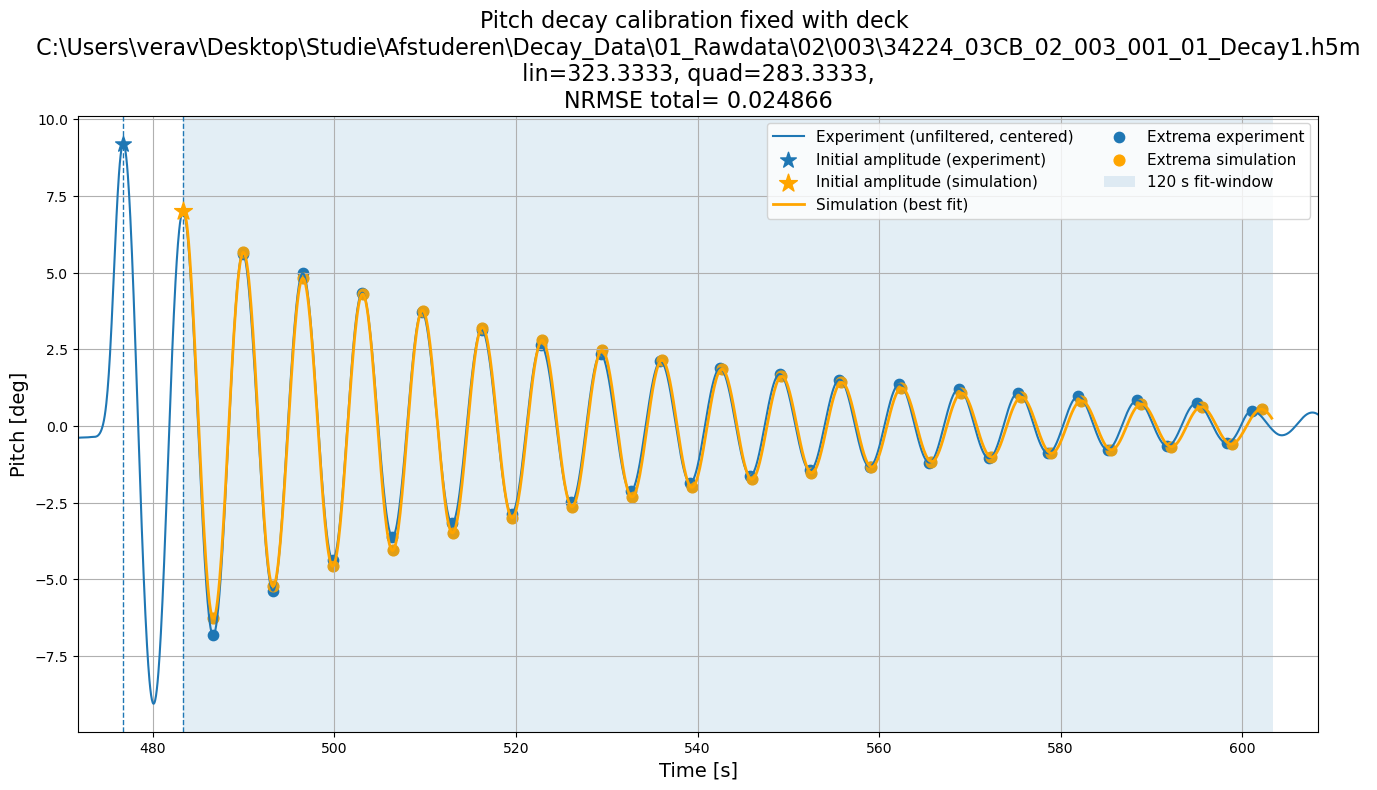

0.5494648664262837


In [35]:

# Plot 1: volledig origineel ongefilterd signaal met A1, A2 en sim-start op A2
plt.figure(figsize=(16, 8))
plt.plot(exp_info["t_unfiltered"], exp_info["z_centered"], label="Experiment (unfiltered, centered)")
plt.scatter(exp_info["t_A1"], exp_info["z_A1"], s=140, marker="*", label=f"Initial amplitude (experiment)", color="#1f77b4", zorder=5)
plt.scatter(exp_info["t_A2"], exp_info["z_A2"], s=180, marker="*", label=f"Initial amplitude (simulation)", color="orange", zorder=5)

# Simulatie in absolute tijd vanaf A2
sim_abs_t = exp_info["t_A2"] + best_fine["t_sim_fit"]
plt.plot(sim_abs_t, best_fine["z_sim_fit"], label="Simulation (best fit)", color="orange", linewidth=2)

# Markers op pieken en dalen in experiment
plt.scatter(
    exp_info["t_A2"] + exp_info["t_exp_peaks_rel"],
    exp_info["z_exp_peaks"],
    s=55,
    label="Extrema experiment",
    marker="o",
    color = "#1f77b4"
)
plt.scatter(
    exp_info["t_A2"] + exp_info["t_exp_troughs_rel"],
    exp_info["z_exp_troughs"],
    s=55,
    marker="o",
    
    color = "#1f77b4"
)

# Markers op pieken en dalen in simulatie
plt.scatter(
    exp_info["t_A2"] + best_fine["t_sim_peaks_rel"],
    best_fine["z_sim_peaks"],
    s=60,
    marker="o",
    color = 'orange'
    
)
plt.scatter(
    exp_info["t_A2"] + best_fine["t_sim_troughs_rel"],
    best_fine["z_sim_troughs"],
    s=60,
    marker="o",
    color = 'orange',
    label="Extrema simulation",
    
)

plt.axvline(exp_info["t_A1"], linestyle="--", linewidth=1)
plt.axvline(exp_info["t_A2"], linestyle="--", linewidth=1)
plt.axvspan(exp_info["fit_start_abs"], exp_info["fit_end_abs"], alpha=0.12, label="120 s fit-window")

plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
plt.ylabel("Pitch [deg]", fontsize=LABEL_SIZE)
plt.title(
    f"Pitch decay calibration fixed with deck \n {exp_path} \n "
    f"lin={best_fine['c_lin']:.4f}, quad={best_fine['c_quad']:.4f}, \n"
    f"NRMSE total= {best_fine['score']:.6f}",
    fontsize=TITLE_SIZE,
)
plt.legend(fontsize=11, ncol=2)
plt.xlim(exp_info["t_A1"] - lookback_window, exp_info["fit_end_abs"] + 5)
plt.savefig("Pitch_decay_fit_003_001.png", dpi=300)
plt.show()

print(best_fine["z_sim_peaks"][-1])
